# Spectroscopic Limited Maximum Efficiency (SLME) and Blank et. al.

#### Pre-requisites:
* Optics
* Band Structure (for the band gaps)

1) Import the necessary libraries.

In [1]:
import solphin.band_structure as band_structure
import solphin.db_fom as db_fom
import solphin.optics as optics

2) Define the chosen spectrum and the illuminance (if necessary).

In [2]:
print("Available Spectra:")
for name in db_fom.SPECTRUM_FILES.keys():
    print(name)

Available Spectra:
AM1.5
Fluorescent
Blue LED
Green LED
Red LED
White LED
IR LED
LED-B1
LED-B2
LED-B3
LED-B4
LED-B5
LED-BH1
LED-RGB1
LED-V1
LED-V2


In [10]:
spectrum_type = "AM1.5"
target_lux = 1000  # Illuminance the indoor spectra are normalised to (ignored for AM1.5 outdoor)

3) Load or specify the band gap(s).

In [4]:
bs = band_structure.get_band_structure("../tests/data/Cu2GeS3/BAND_SP_HDFT", splits=7, code="vasp")
E_gap_fundamental = bs.get_band_gap()["energy"]
E_gap_direct = bs.get_direct_band_gap()

print(f"Loaded fundamental band gap of {E_gap_fundamental:.2f} eV")
print(f"Loaded direct band gap of {E_gap_direct:.2f} eV")

Loaded fundamental band gap of 1.39 eV
Loaded direct band gap of 1.39 eV


4) Perform the SLME and Blank et. al. Analysis.

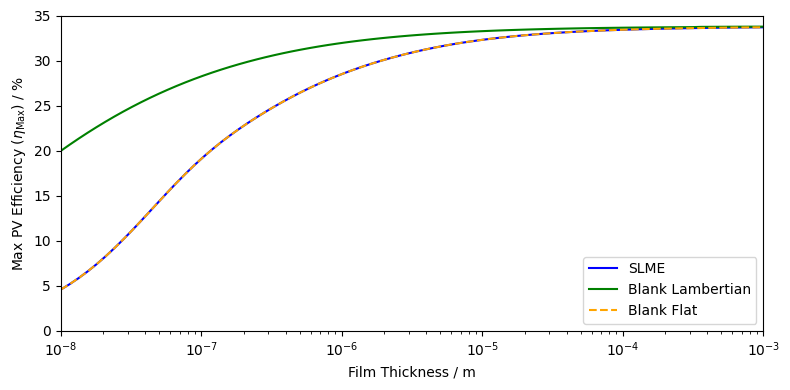

In [11]:
%matplotlib inline
eff_flat, eff_lam, eff_slme, thicknesses, = optics.make_blank_plot(
    optics_directory = "../tests/data/Cu2GeS3/OPT_hybrid", 
    direct_gap=E_gap_direct, 
    indirect_gap=E_gap_direct, 
    spectrum_type=spectrum_type,
    target_lux=target_lux,
    )